In [ ]:
import pickle
import numpy as np
import pandas as pd
import zipfile
import os
import glob
import matplotlib.pyplot as plt


ZIP_PATH = "DATASET.zip"
EXTRACT_DIR = "data_extracted"


os.makedirs(EXTRACT_DIR, exist_ok=True)

with zipfile.ZipFile(ZIP_PATH, "r") as zf:
    zf.extractall(EXTRACT_DIR)
    print("Files inside your ZIP:")
    for name in zf.namelist():
        print(f"   {name}")

pkl_files = sorted(glob.glob(os.path.join(EXTRACT_DIR, "**/*.pkl"), recursive=True))
print(f"\nTotal PKL files found: {len(pkl_files)}")

with open(pkl_files[0], "rb") as fh:
    first_file = pickle.load(fh)

print(f"\nType of data inside PKL: {type(first_file)}")

if isinstance(first_file, pd.DataFrame):
    print(f"\nShape (rows x columns): {first_file.shape}")
    print(f"\nColumn names: {list(first_file.columns)}")
    print(f"\nFirst 2 rows:")
    print(first_file.head(2))


print("\n--- Simulation Parameters ---")
row = first_file.iloc[0]
print(f"Distance          : {row['z_km']} km")
print(f"Symbols sent      : {row['n_symbols']}")
print(f"Average power     : {row['p_ave_dbm']} dBm")
print(f"Noise figure      : {row['noise_figure_db']} dB")
print(f"Nonlinearity gamma: {row['gamma']}")



sample_orig    = first_file["points_orig"].iloc[0]
sample_shifted = first_file["points_shifted"].iloc[0]

print(f"\npoints_orig type    : {type(sample_orig)}")
print(f"points_orig length  : {len(sample_orig)}")
print(f"First 5 ideal points: {sample_orig[:5]}")

print(f"\npoints_shifted type    : {type(sample_shifted)}")
print(f"points_shifted length  : {len(sample_shifted)}")
print(f"First 5 received points: {sample_shifted[:5]}")

print("\n--- Reading one symbol ---")
sym = sample_orig[0]
print(f"Symbol : {sym}")
print(f"I value (real)     : {sym.real}")
print(f"Q value (imaginary): {sym.imag}")

Files inside your ZIP:
   NEW DATASET/
   NEW DATASET/Downloadsdata_collected_errorstat_onepol_pilot_3channel_noise_2_16QAM_NoL3_nch_1_pavedbm_-1.pkl
   NEW DATASET/Downloadsdata_collected_errorstat_onepol_pilot_3channel_noise_2_16QAM_NoL3_nch_1_pavedbm_-3.pkl
   NEW DATASET/Downloadsdata_collected_errorstat_onepol_pilot_3channel_noise_2_16QAM_NoL3_nch_1_pavedbm_-5.pkl
   NEW DATASET/Downloadsdata_collected_errorstat_onepol_pilot_3channel_noise_2_16QAM_NoL3_nch_1_pavedbm_1.pkl
   NEW DATASET/Downloadsdata_collected_errorstat_onepol_pilot_3channel_noise_2_16QAM_NoL3_nch_1_pavedbm_3.pkl
   NEW DATASET/Downloadsdata_collected_errorstat_onepol_pilot_3channel_noise_2_16QAM_NoL3_nch_1_pavedbm_5.pkl
   NEW DATASET/Downloadsdata_collected_errorstat_onepol_pilot_3channel_noise_2_16QAM_NoL3_nch_1_pavedbm_7.pkl

Total PKL files found: 7

Type of data inside PKL: <class 'pandas.DataFrame'>

Shape (rows x columns): (16, 23)

Column names: ['run', 'n_channels', 'n_polarisations', 'n_symbols', 'p_ave

Total rows (runs) : 112
Columns           : ['run', 'n_channels', 'n_polarisations', 'n_symbols', 'p_ave_dbm', 'z_km', 'scale_coef', 'noise_figure_db', 'gamma', 'z_span', 'dispersion_parameter', 'dz', 'points_orig', 'points_shifted', 'points_shifted_wo_noise', 'ber', 'q', 'evm', 'mi', 'ber_w_noise', 'q_w_noise', 'evm_w_noise', 'mi_w_noise']

Total tx symbols : 112
Total rx samples : 112

Example ideal    : [ 0.00891251+0.02673753j  0.02673753-0.00891251j  0.00891251+0.02673753j
 ...  0.00891251+0.00891251j -0.02673753-0.00891251j
 -0.00891251-0.00891251j]  → I=[ 0.00891251  0.02673753  0.00891251 ...  0.00891251 -0.02673753
 -0.00891251], Q=[ 0.02673753 -0.00891251  0.02673753 ...  0.00891251 -0.00891251
 -0.00891251]
Example received : [ 0.00787591+0.0311845j   0.02735122-0.01108019j  0.00593141+0.024099j
 ...  0.00555574+0.01096758j -0.02497114-0.00687431j
 -0.00933805-0.00401569j]  → I=[ 0.00787591  0.02735122  0.00593141 ...  0.00555574 -0.02497114
 -0.00933805], Q=[ 0.0311845  -0.

C:\Users\user\AppData\Local\Temp\ipykernel_2532\222632764.py:88: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
C:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


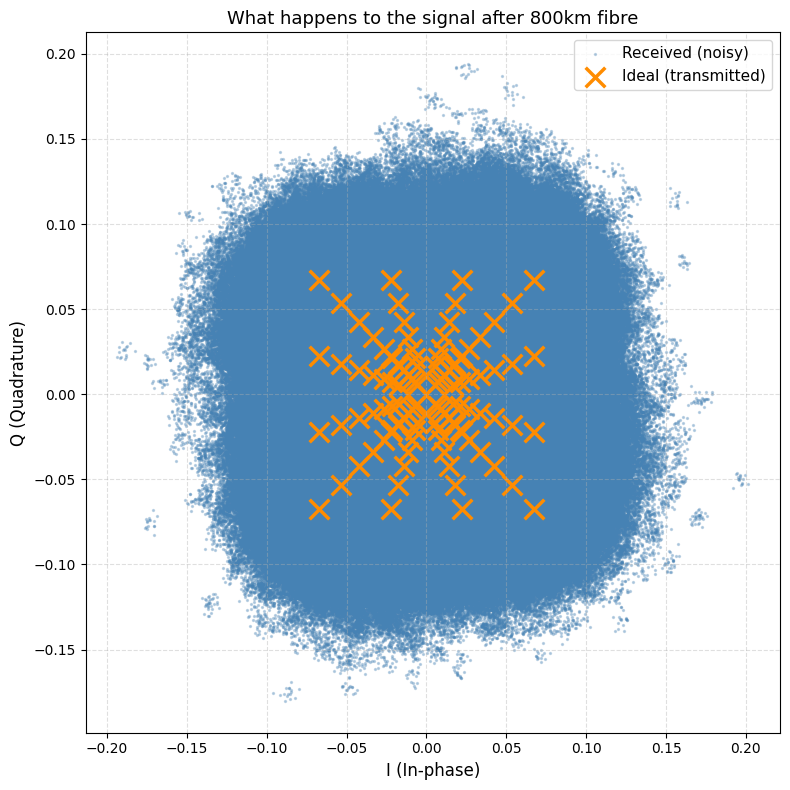

Saved: tx_symbols.npy, rx_samples.npy


In [ ]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import zipfile
import os
import glob

EXTRACT_DIR = "data_extracted"
pkl_files   = sorted(glob.glob(os.path.join(EXTRACT_DIR, "**/*.pkl"), recursive=True))

frames = []
for fpath in pkl_files:
    with open(fpath, "rb") as fh:
        obj = pickle.load(fh)
    if isinstance(obj, pd.DataFrame):
        frames.append(obj)
    elif isinstance(obj, list):
        try:
            frames.append(pd.DataFrame(obj))
        except:
            pass

df = pd.concat(frames, ignore_index=True)
print(f"Total rows (runs) : {len(df)}")
print(f"Columns           : {list(df.columns)}")

def load_flat(path):
    data = np.load(path, allow_pickle=True)
    if data.ndim == 1 and np.iscomplexobj(data): return data
    return np.concatenate([np.array(x).flatten() for x in data]).astype(complex)

tx_symbols = load_flat("tx_symbols.npy")
rx_samples  = load_flat("rx_samples.npy")



print(f"\nTotal tx symbols : {len(tx_symbols)}")
print(f"Total rx samples : {len(rx_samples)}")
print(f"\nExample ideal    : {tx_symbols[0]}  → I={tx_symbols[0].real}, Q={tx_symbols[0].imag}")
print(f"Example received : {rx_samples[0]}  → I={rx_samples[0].real}, Q={rx_samples[0].imag}")
print(f"Shift/Error      : {rx_samples[0] - tx_symbols[0]}")

unique_symbols = np.unique(tx_symbols)
print(f"\nUnique ideal symbols: {len(unique_symbols)}")
print("They are:")
for s in unique_symbols:
    print(f"   I={s.real:+.1f}  Q={s.imag:+.1f}")

fig, ax = plt.subplots(figsize=(8, 8))

ax.scatter(rx_samples.real[:5000], rx_samples.imag[:5000],
           s=2, alpha=0.3, color="steelblue", label="Received (noisy)")

ax.scatter(unique_symbols.real, unique_symbols.imag,
           s=200, marker="x", color="darkorange",
           linewidths=2.5, label="Ideal (transmitted)")

ax.set_xlabel("I (In-phase)", fontsize=12)
ax.set_ylabel("Q (Quadrature)", fontsize=12)
ax.set_title("What happens to the signal after 800km fibre", fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

np.save("tx_symbols.npy", tx_symbols)
np.save("rx_samples.npy",  rx_samples)
print("Saved: tx_symbols.npy, rx_samples.npy")

In [ ]:
!pip install numpy==1.26.4
!pip install scipy==1.11.4
!pip install scikit-learn==1.3.2


[notice] A new release of pip available: 22.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip available: 22.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip available: 22.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Symbol amplitudes (distances from origin):
  I=-0.1 Q=-0.1  →  amplitude = 0.0950
  I=-0.1 Q=-0.0  →  amplitude = 0.0708
  I=-0.1 Q=+0.0  →  amplitude = 0.0708
  I=-0.1 Q=+0.1  →  amplitude = 0.0950
  I=-0.1 Q=-0.1  →  amplitude = 0.0754
  I=-0.1 Q=-0.0  →  amplitude = 0.0562
  I=-0.1 Q=+0.0  →  amplitude = 0.0562
  I=-0.1 Q=+0.1  →  amplitude = 0.0754
  I=-0.0 Q=-0.0  →  amplitude = 0.0599
  I=-0.0 Q=-0.0  →  amplitude = 0.0447
  I=-0.0 Q=+0.0  →  amplitude = 0.0447
  I=-0.0 Q=+0.0  →  amplitude = 0.0599
  I=-0.0 Q=-0.0  →  amplitude = 0.0476
  I=-0.0 Q=-0.0  →  amplitude = 0.0355
  I=-0.0 Q=+0.0  →  amplitude = 0.0355
  I=-0.0 Q=+0.0  →  amplitude = 0.0476
  I=-0.0 Q=-0.0  →  amplitude = 0.0378
  I=-0.0 Q=-0.0  →  amplitude = 0.0282
  I=-0.0 Q=+0.0  →  amplitude = 0.0282
  I=-0.0 Q=+0.0  →  amplitude = 0.0378
  I=-0.0 Q=-0.1  →  amplitude = 0.0708
  I=-0.0 Q=-0.0  →  amplitude = 0.0317
  I=-0.0 Q=+0.0  →  amplitude = 0.0317
  I=-0.0 Q=+0.1  →  amplitude = 0.0708
  I=-0.0 Q=-0.0  →  a

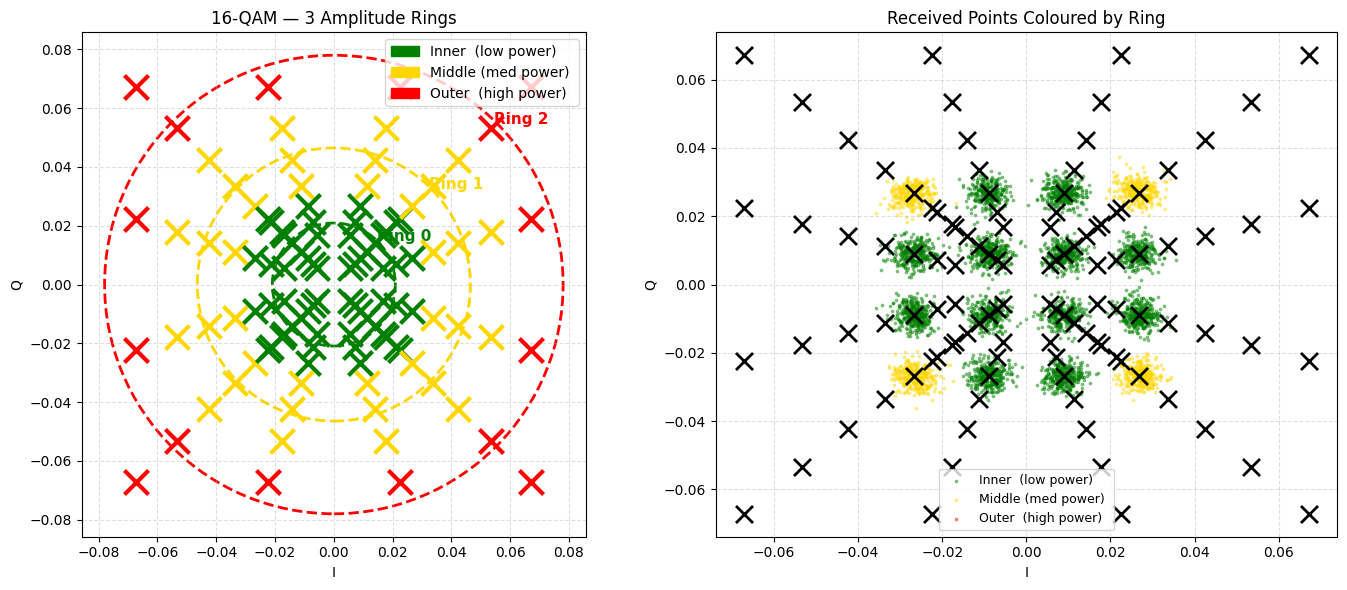

Saved: sym_to_ring.pkl, tx_rings.npy


In [ ]:
import numpy as np
import pickle
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.cluster import KMeans

tx_symbols     = np.concatenate(np.load("tx_symbols.npy"))
rx_samples     = np.concatenate(np.load("rx_samples.npy"))
unique_symbols = np.unique(tx_symbols)

print("Symbol amplitudes (distances from origin):")
for s in unique_symbols:
    amp = np.abs(s)
    print(f"  I={s.real:+.1f} Q={s.imag:+.1f}  →  amplitude = {amp:.4f}")

amplitudes = np.abs(unique_symbols).reshape(-1, 1)

km = KMeans(n_clusters=3, n_init=10, random_state=0)
km.fit(amplitudes)
labels = km.labels_

centres = km.cluster_centers_.flatten()
order   = np.argsort(centres)
remap   = {old: new for new, old in enumerate(order)}
labels  = np.array([remap[l] for l in labels])

sym_to_ring = {s: labels[i] for i, s in enumerate(unique_symbols)}


print("\n--- Ring Assignments ---")
ring_names = {0: "Inner  (low power) ",
              1: "Middle (med power) ",
              2: "Outer  (high power)"}

for r in range(3):
    syms_in_ring = [s for s, v in sym_to_ring.items() if v == r]
    mean_amp     = np.mean([np.abs(s) for s in syms_in_ring])
    print(f"\nRing {r} — {ring_names[r]}")
    print(f"  Mean amplitude : {mean_amp:.4f}")
    print(f"  Symbols ({len(syms_in_ring)})  :", end=" ")
    for s in sorted(syms_in_ring, key=lambda x: x.real):
        print(f"({s.real:+.0f},{s.imag:+.0f})", end="  ")
tx_rings = np.array([sym_to_ring[s] for s in tx_symbols])

print(f"\n\ntx_rings shape: {tx_rings.shape}")
print(f"First 10 ring labels: {tx_rings[:10]}")
print(f"First 10 tx symbols : {[f'({s.real:+.0f},{s.imag:+.0f})' for s in tx_symbols[:10]]}")


ring_colors = {0: "green", 1: "gold", 2: "red"}

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax = axes[0]
for s, r in sym_to_ring.items():
    ax.scatter(s.real, s.imag, color=ring_colors[r],
               s=300, marker="x", linewidths=3, zorder=5)

for r in range(3):
    radius = np.mean([np.abs(s) for s, v in sym_to_ring.items() if v == r])
    circle = plt.Circle((0, 0), radius, fill=False,
                         color=ring_colors[r], linestyle="--", linewidth=2)
    ax.add_patch(circle)
    ax.annotate(f"Ring {r}", xy=(radius * 0.7, radius * 0.7),
                color=ring_colors[r], fontsize=11, fontweight="bold")

patches = [mpatches.Patch(color=ring_colors[r], label=ring_names[r])
           for r in range(3)]
ax.legend(handles=patches, fontsize=10)
ax.set_aspect("equal")
ax.set_title("16-QAM — 3 Amplitude Rings", fontsize=12)
ax.set_xlabel("I"); ax.set_ylabel("Q")
ax.grid(True, linestyle="--", alpha=0.4)

ax = axes[1]
for r in range(3):
    mask = tx_rings[:5000] == r
    ax.scatter(rx_samples[:5000][mask].real,
               rx_samples[:5000][mask].imag,
               s=3, alpha=0.4, color=ring_colors[r],
               label=ring_names[r])
for s in unique_symbols:
    ax.scatter(s.real, s.imag, s=150, marker="x",
               color="black", linewidths=2, zorder=5)

ax.legend(fontsize=9)
ax.set_title("Received Points Coloured by Ring", fontsize=12)
ax.set_xlabel("I"); ax.set_ylabel("Q")
ax.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()


with open("sym_to_ring.pkl", "wb") as f:
    pickle.dump(sym_to_ring, f)
np.save("tx_rings.npy", tx_rings)
print("Saved: sym_to_ring.pkl, tx_rings.npy")

Total symbols: 29360128

First 5 triplets in the sequence:
  t=1: prev=(+0,+0)  curr=(+0,-0)  next=(+0,+0)
       rings: 0 → 0 → 0
  t=2: prev=(+0,-0)  curr=(+0,+0)  next=(+0,-0)
       rings: 0 → 0 → 0
  t=3: prev=(+0,+0)  curr=(+0,-0)  next=(-0,+0)
       rings: 0 → 0 → 0
  t=4: prev=(+0,-0)  curr=(-0,+0)  next=(-0,+0)
       rings: 0 → 0 → 1
  t=5: prev=(-0,+0)  curr=(-0,+0)  next=(-0,-0)
       rings: 0 → 1 → 0

--- Model Comparison ---
Model A (Symbol-Triplet) contexts : 28684
  Theoretical maximum             : 16×16×16 = 4096

Model B (Ring-Triplet) contexts   : 433
  Theoretical maximum             : 3×16×3 = 144

Reduction factor                  : 66.2×

Model A avg samples per context   : 1024
Model B avg samples per context   : 67806
  (More samples = better GMM fit)


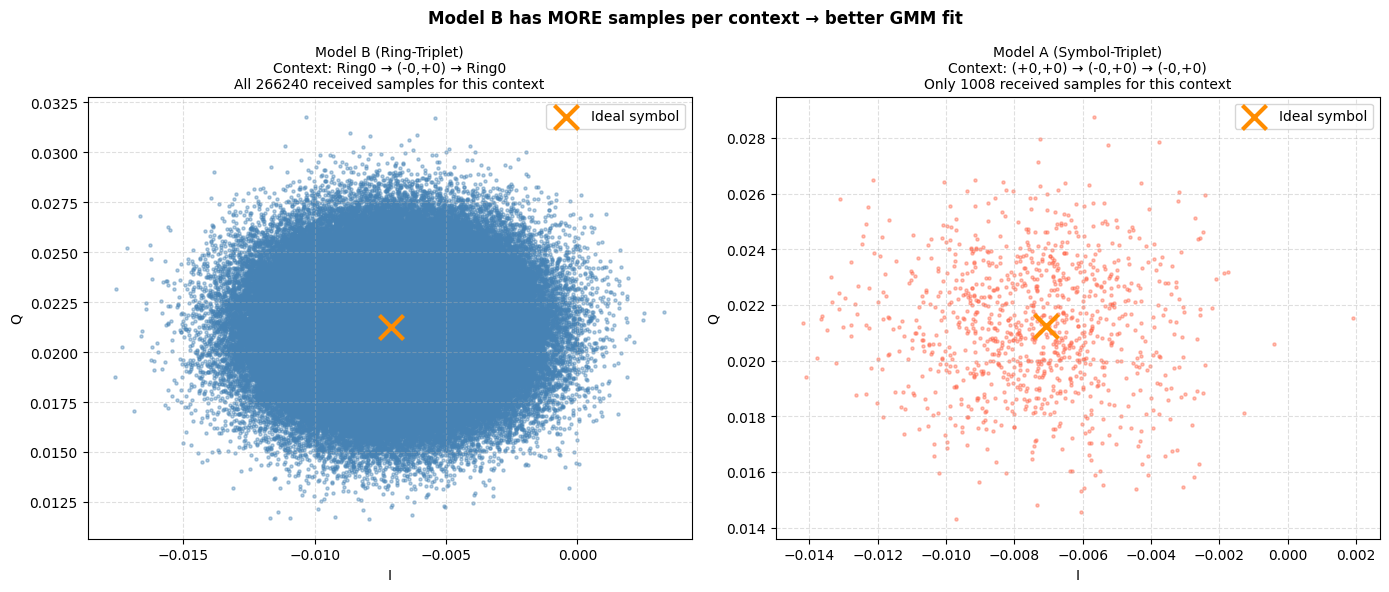

Saved: symbol_triplet_data.pkl, ring_triplet_data.pkl


In [ ]:
import numpy as np
import pickle
import matplotlib.pyplot as plt
from collections import defaultdict

tx_symbols = np.load("tx_symbols.npy").flatten()
rx_samples  = np.load("rx_samples.npy").flatten()
tx_rings    = np.load("tx_rings.npy")
N           = len(tx_symbols)
print(f"Total symbols: {N}")



print("\nFirst 5 triplets in the sequence:")
for t in range(1, 6):
    prev = tx_symbols[t-1]
    curr = tx_symbols[t]
    nxt  = tx_symbols[t+1]
    print(f"  t={t}: prev=({prev.real:+.0f},{prev.imag:+.0f})  "
          f"curr=({curr.real:+.0f},{curr.imag:+.0f})  "
          f"next=({nxt.real:+.0f},{nxt.imag:+.0f})")
    print(f"       rings: {int(tx_rings[t-1])} → {int(tx_rings[t])} → {int(tx_rings[t+1])}")


symbol_triplet_data = defaultdict(list)
ring_triplet_data   = defaultdict(list)

for t in range(1, N - 1):
    prev_sym  = tx_symbols[t - 1]
    curr_sym  = tx_symbols[t]
    next_sym  = tx_symbols[t + 1]

    prev_ring = int(tx_rings[t - 1])
    next_ring = int(tx_rings[t + 1])

    rx_iq = np.array([rx_samples[t].real, rx_samples[t].imag])

    symbol_triplet_data[(prev_sym, curr_sym, next_sym)].append(rx_iq)

    ring_triplet_data[(prev_ring, curr_sym, next_ring)].append(rx_iq)

symbol_triplet_data = {k: np.array(v) for k, v in symbol_triplet_data.items()}
ring_triplet_data   = {k: np.array(v) for k, v in ring_triplet_data.items()}

print("\n--- Model Comparison ---")
print(f"Model A (Symbol-Triplet) contexts : {len(symbol_triplet_data)}")
print(f"  Theoretical maximum             : 16\u00d716\u00d716 = {16**3}")
print(f"\nModel B (Ring-Triplet) contexts   : {len(ring_triplet_data)}")
print(f"  Theoretical maximum             : 3\u00d716\u00d73 = {3*16*3}")
print(f"\nReduction factor                  : {len(symbol_triplet_data)/max(len(ring_triplet_data),1):.1f}\u00d7")

counts_A = [v.shape[0] for v in symbol_triplet_data.values()]
counts_B = [v.shape[0] for v in ring_triplet_data.values()]
print(f"\nModel A avg samples per context   : {np.mean(counts_A):.0f}")
print(f"Model B avg samples per context   : {np.mean(counts_B):.0f}")
print(f"  (More samples = better GMM fit)")

best_key = max(ring_triplet_data, key=lambda k: ring_triplet_data[k].shape[0])
pts      = ring_triplet_data[best_key]
cx, cy   = best_key[1].real, best_key[1].imag

matching_A_keys = [k for k in symbol_triplet_data if k[1] == best_key[1]]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax = axes[0]
ax.scatter(pts[:,0], pts[:,1], s=5, alpha=0.4, color="steelblue")
ax.scatter([cx], [cy], s=300, marker="x", color="darkorange",
           linewidths=3, label="Ideal symbol")
ax.set_title(f"Model B (Ring-Triplet)\n"
             f"Context: Ring{best_key[0]} → ({cx:+.0f},{cy:+.0f}) → Ring{best_key[2]}\n"
             f"All {pts.shape[0]} received samples for this context",
             fontsize=10)
ax.set_xlabel("I"); ax.set_ylabel("Q")
ax.legend(); ax.grid(True, linestyle="--", alpha=0.4)

ax = axes[1]
if matching_A_keys:
    key_a = matching_A_keys[0]
    pts_a = symbol_triplet_data[key_a]
    ax.scatter(pts_a[:,0], pts_a[:,1], s=5, alpha=0.4, color="tomato")
    ax.scatter([cx], [cy], s=300, marker="x", color="darkorange",
               linewidths=3, label="Ideal symbol")
    ax.set_title(f"Model A (Symbol-Triplet)\n"
                 f"Context: ({key_a[0].real:+.0f},{key_a[0].imag:+.0f}) → "
                 f"({cx:+.0f},{cy:+.0f}) → ({key_a[2].real:+.0f},{key_a[2].imag:+.0f})\n"
                 f"Only {pts_a.shape[0]} received samples for this context",
                 fontsize=10)
    ax.set_xlabel("I"); ax.set_ylabel("Q")
    ax.legend(); ax.grid(True, linestyle="--", alpha=0.4)

plt.suptitle("Model B has MORE samples per context → better GMM fit",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

with open("symbol_triplet_data.pkl", "wb") as f:
    pickle.dump(symbol_triplet_data, f)
with open("ring_triplet_data.pkl", "wb") as f:
    pickle.dump(ring_triplet_data, f)
print("Saved: symbol_triplet_data.pkl, ring_triplet_data.pkl")

Fitting Model A GMMs (Symbol-Triplet)...
Total contexts to fit: 28684
  300/28684 fitted...
  600/28684 fitted...
  900/28684 fitted...
  1200/28684 fitted...
  1500/28684 fitted...
  1800/28684 fitted...
  2100/28684 fitted...
  2400/28684 fitted...
  2700/28684 fitted...
  3000/28684 fitted...
  3300/28684 fitted...
  3600/28684 fitted...
  3900/28684 fitted...
  4200/28684 fitted...
  4500/28684 fitted...
  4800/28684 fitted...
  5100/28684 fitted...
  5400/28684 fitted...
  5700/28684 fitted...
  6000/28684 fitted...
  6300/28684 fitted...
  6600/28684 fitted...
  6900/28684 fitted...
  7200/28684 fitted...
  7500/28684 fitted...
  7800/28684 fitted...
  8100/28684 fitted...
  8400/28684 fitted...
  8700/28684 fitted...
  9000/28684 fitted...
  9300/28684 fitted...
  9600/28684 fitted...
  9900/28684 fitted...
  10200/28684 fitted...
  10500/28684 fitted...
  10800/28684 fitted...
  11100/28684 fitted...
  11400/28684 fitted...
  11700/28684 fitted...
  12000/28684 fitted...
  1230

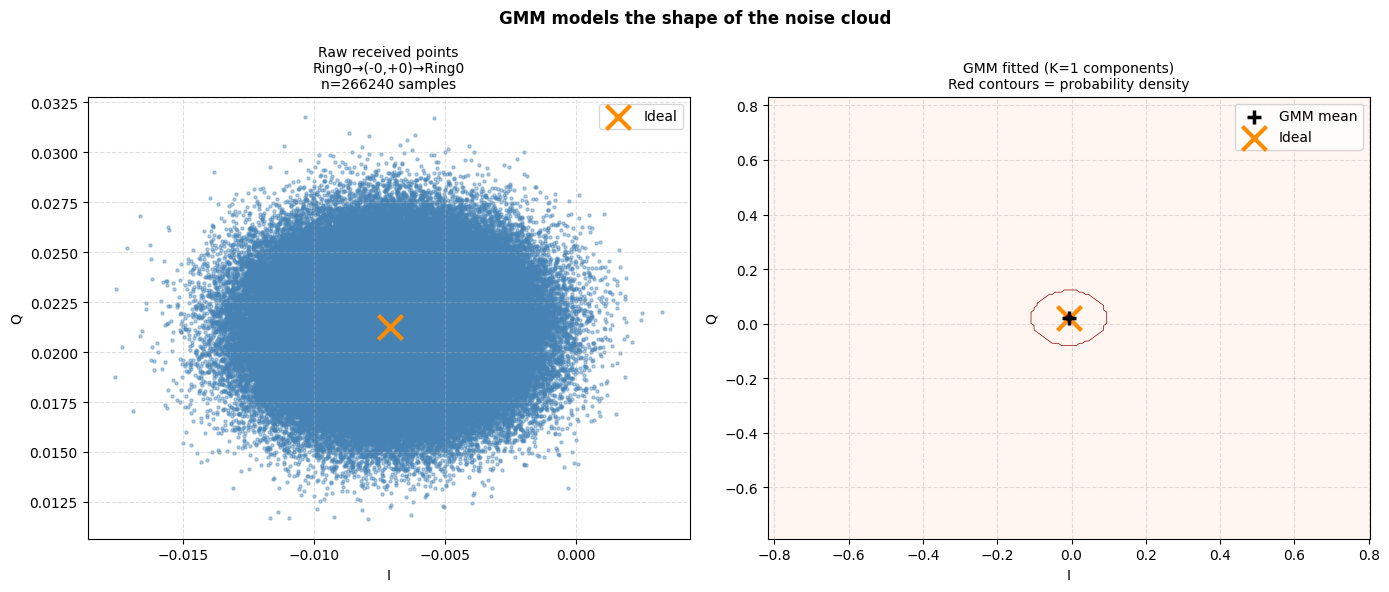

Saved: gmm_A.pkl, gmm_B.pkl


In [ ]:
import numpy as np
import pickle
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
import warnings
warnings.filterwarnings("ignore")


with open("symbol_triplet_data.pkl", "rb") as f:
    symbol_triplet_data = pickle.load(f)
with open("ring_triplet_data.pkl", "rb") as f:
    ring_triplet_data = pickle.load(f)

MIN_SAMPLES = 10
MAX_K       = 5

def fit_gmm(points):
    """
    Fit a 2D GMM to received [I, Q] points.
    Tries K = 1, 2, 3, 4, 5 and picks best by BIC.
    Lower BIC = better model fit (without overfitting).
    """
    n = points.shape[0]
    if n < MIN_SAMPLES:
        return None

    best_gmm = None
    best_bic = np.inf

    for k in range(1, min(MAX_K + 1, n)):
        gmm = GaussianMixture(
            n_components    = k,
            covariance_type = "full",
            max_iter        = 200,
            n_init          = 3,
            random_state    = 42
        )
        gmm.fit(points)
        bic = gmm.bic(points)

        if bic < best_bic:
            best_bic = bic
            best_gmm = gmm

    return best_gmm

print("Fitting Model A GMMs (Symbol-Triplet)...")
print(f"Total contexts to fit: {len(symbol_triplet_data)}")

gmm_A    = {}
skipped  = 0

for i, (key, pts) in enumerate(symbol_triplet_data.items()):
    g = fit_gmm(pts)
    if g is not None:
        gmm_A[key] = g
    else:
        skipped += 1
    if (i+1) % 300 == 0:
        print(f"  {i+1}/{len(symbol_triplet_data)} fitted...")

print(f"Model A: {len(gmm_A)} GMMs fitted, {skipped} skipped (too few samples)")

print(f"\nFitting Model B GMMs (Ring-Triplet)...")
print(f"Total contexts to fit: {len(ring_triplet_data)}")

gmm_B   = {}
skipped = 0

for key, pts in ring_triplet_data.items():
    g = fit_gmm(pts)
    if g is not None:
        gmm_B[key] = g
    else:
        skipped += 1

print(f"Model B: {len(gmm_B)} GMMs fitted, {skipped} skipped")


print("\n--- Example GMM from Model B ---")
key_ex = next(iter(gmm_B))
g_ex   = gmm_B[key_ex]
sym    = key_ex[1]

print(f"Context : Ring{key_ex[0]} → ({sym.real:+.1f},{sym.imag:+.1f}) → Ring{key_ex[2]}")
print(f"K chosen: {g_ex.n_components} Gaussian components")
print(f"Weights : {np.round(g_ex.weights_, 4)}  (must sum to 1.0)")
print(f"Means   :")
for j, m in enumerate(g_ex.means_):
    print(f"  Component {j}: I={m[0]:+.4f}, Q={m[1]:+.4f}")
print(f"Covariances (shape of each blob):")
for j, c in enumerate(g_ex.covariances_):
    print(f"  Component {j}: {np.round(c, 6)}")

best_key = max(ring_triplet_data, key=lambda k: ring_triplet_data[k].shape[0])
pts      = ring_triplet_data[best_key]
g        = gmm_B[best_key]
sym      = best_key[1]

margin = 0.8
xi = np.linspace(pts[:,0].min()-margin, pts[:,0].max()+margin, 200)
yi = np.linspace(pts[:,1].min()-margin, pts[:,1].max()+margin, 200)
XX, YY = np.meshgrid(xi, yi)
XY     = np.column_stack([XX.ravel(), YY.ravel()])
pdf    = np.exp(g.score_samples(XY)).reshape(200, 200)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax = axes[0]
ax.scatter(pts[:,0], pts[:,1], s=5, alpha=0.4, color="steelblue")
ax.scatter([sym.real], [sym.imag], s=300, marker="x",
           color="darkorange", linewidths=3, label="Ideal")
ax.set_title(f"Raw received points\n"
             f"Ring{best_key[0]}→({sym.real:+.0f},{sym.imag:+.0f})→Ring{best_key[2]}\n"
             f"n={pts.shape[0]} samples", fontsize=10)
ax.set_xlabel("I"); ax.set_ylabel("Q")
ax.legend(); ax.grid(True, linestyle="--", alpha=0.4)

ax = axes[1]
ax.scatter(pts[:,0], pts[:,1], s=5, alpha=0.2, color="steelblue")
ax.contourf(XX, YY, pdf, levels=12, cmap="Reds", alpha=0.6)
ax.contour(XX, YY, pdf, levels=8, colors="darkred", linewidths=0.5)
for mean in g.means_:
    ax.scatter(*mean, s=100, marker="+", color="black",
               linewidths=2.5, zorder=5, label="GMM mean")
ax.scatter([sym.real], [sym.imag], s=300, marker="x",
           color="darkorange", linewidths=3, label="Ideal")
ax.set_title(f"GMM fitted (K={g.n_components} components)\n"
             f"Red contours = probability density", fontsize=10)
ax.set_xlabel("I"); ax.set_ylabel("Q")
ax.legend(); ax.grid(True, linestyle="--", alpha=0.4)

plt.suptitle("GMM models the shape of the noise cloud", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

with open("gmm_A.pkl", "wb") as f:
    pickle.dump(gmm_A, f)
with open("gmm_B.pkl", "wb") as f:
    pickle.dump(gmm_B, f)
print("Saved: gmm_A.pkl, gmm_B.pkl")

Log-Likelihood  Model A: 7.9871
Log-Likelihood  Model B: 7.8736
Difference (B-A): -0.1135

BER: 0.122645
EVM: 12.781%
Q-factor: 1.1619
Q-factor (dB): 1.30 dB

Model A GMMs: 28672
Model B GMMs: 432
Reduction: 66.4x fewer models


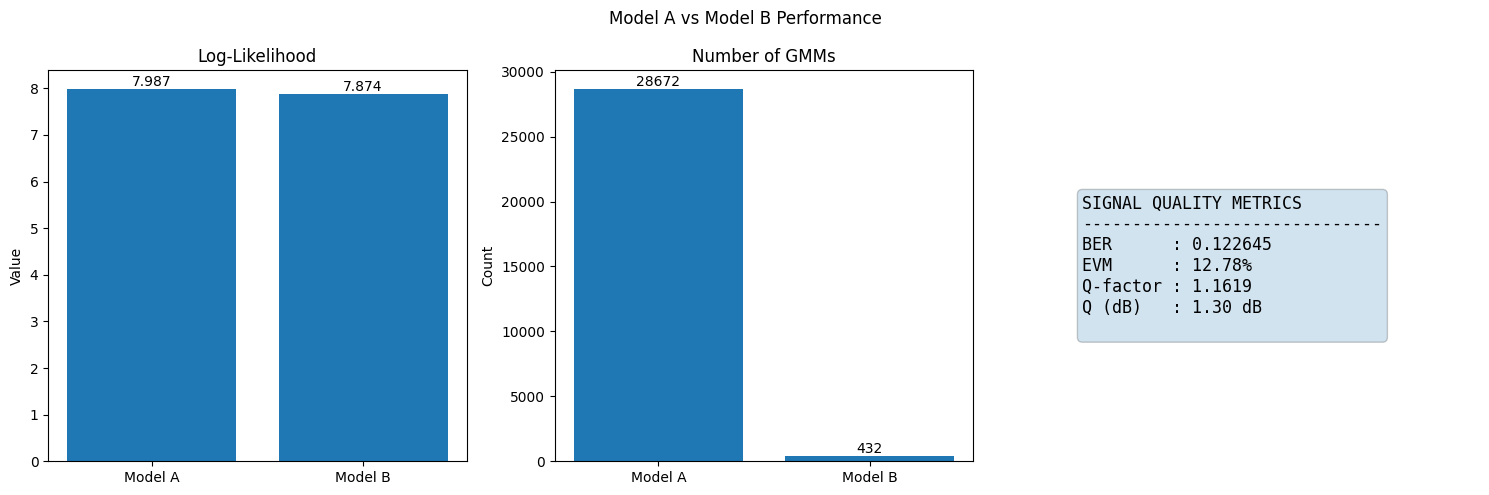

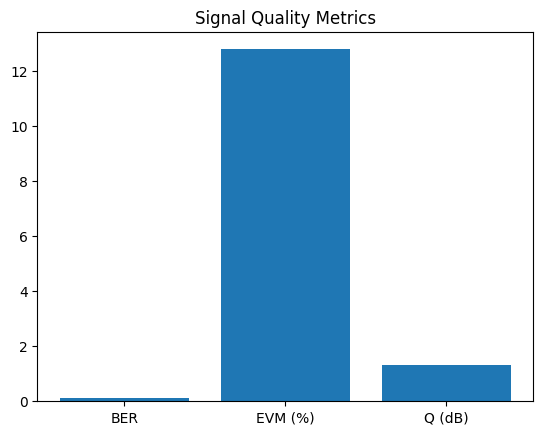


Per-Run Metrics:
 run      BER  EVM (%)  Q-factor  Q (dB)
   0 0.122711   12.765    1.1615    1.30
   1 0.122450   12.778    1.1628    1.31
   2 0.122339   12.796    1.1634    1.31
   3 0.122313   12.772    1.1635    1.32
   4 0.122562   12.778    1.1623    1.31
   5 0.122617   12.786    1.1620    1.30
   6 0.122966   12.794    1.1603    1.29
   7 0.122951   12.788    1.1604    1.29
   8 0.122449   12.778    1.1628    1.31
   9 0.122750   12.778    1.1613    1.30
  10 0.122989   12.784    1.1602    1.29
  11 0.122645   12.781    1.1619    1.30
  12 0.122521   12.776    1.1625    1.31
  13 0.122638   12.780    1.1619    1.30
  14 0.122540   12.777    1.1624    1.31
  15 0.122619   12.784    1.1620    1.30

Saved: per_run_metrics.csv


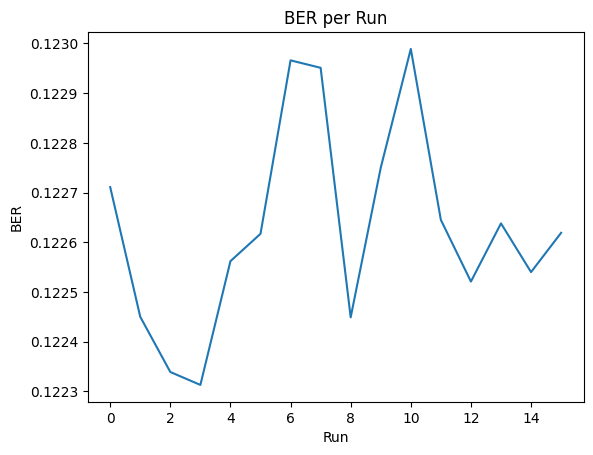

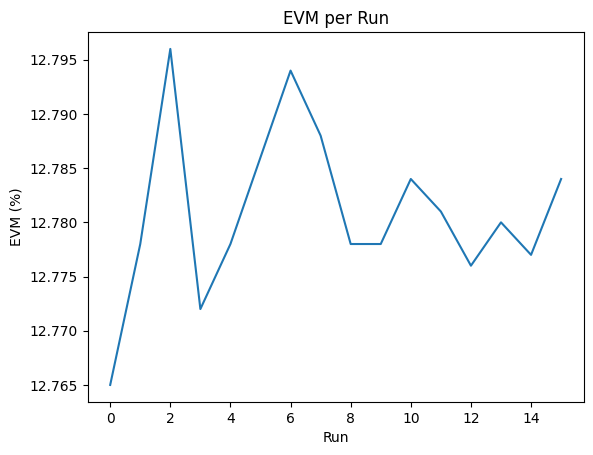

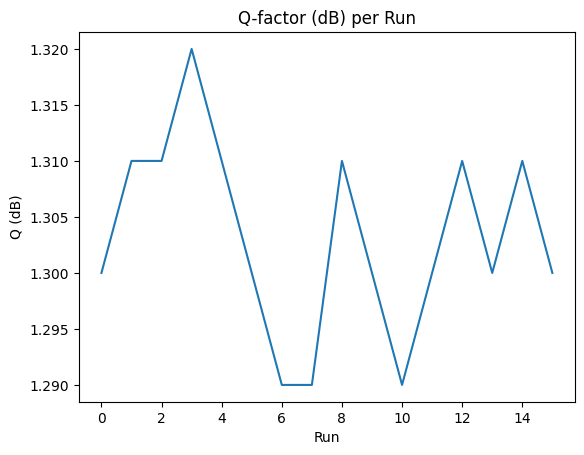

In [ ]:
import numpy as np
import pickle
import matplotlib.pyplot as plt
import pandas as pd
from scipy.special import erfinv
import warnings
warnings.filterwarnings("ignore")

tx_symbols = np.concatenate(np.load("tx_symbols.npy"))
rx_samples = np.concatenate(np.load("rx_samples.npy"))

with open("gmm_A.pkl", "rb") as f: gmm_A = pickle.load(f)
with open("gmm_B.pkl", "rb") as f: gmm_B = pickle.load(f)
with open("symbol_triplet_data.pkl", "rb") as f: sym_data = pickle.load(f)
with open("ring_triplet_data.pkl",   "rb") as f: ring_data = pickle.load(f)

unique_symbols = np.unique(tx_symbols)
tx = tx_symbols[1:-1]
rx = rx_samples[1:-1]
N = 2000000
tx_small = tx[:N]
rx_small = rx[:N]

def log_likelihood(gmm_dict, triplet_data):
    total_ll, total_n = 0.0, 0
    for key, pts in triplet_data.items():
        if key in gmm_dict and pts.shape[0] >= 2:
            ll = gmm_dict[key].score(pts)
            total_ll += ll * pts.shape[0]
            total_n  += pts.shape[0]
    return total_ll / total_n if total_n > 0 else np.nan

ll_A = log_likelihood(gmm_A, sym_data)
ll_B = log_likelihood(gmm_B, ring_data)

print(f"Log-Likelihood  Model A: {ll_A:.4f}")
print(f"Log-Likelihood  Model B: {ll_B:.4f}")
print(f"Difference (B-A): {ll_B - ll_A:+.4f}")

def quantize_levels(vals, levels):
    idx = np.searchsorted(levels, vals)
    idx = np.clip(idx, 1, len(levels)-1)
    left = levels[idx-1]
    right = levels[idx]
    idx -= (np.abs(vals - left) < np.abs(vals - right))
    return levels[idx]

def compute_ber(tx_arr, rx_arr, constellation):
    M = len(constellation)
    bits_per_sym = int(np.log2(M))

    real_levels = np.sort(np.unique(constellation.real))
    imag_levels = np.sort(np.unique(constellation.imag))

    decided_real = quantize_levels(rx_arr.real, real_levels)
    decided_imag = quantize_levels(rx_arr.imag, imag_levels)
    decided = decided_real + 1j * decided_imag

    ser = np.mean(decided != tx_arr)
    return ser / bits_per_sym

ber = compute_ber(tx_small, rx_small, unique_symbols)
print(f"\nBER: {ber:.6f}")


def compute_evm(tx_arr, rx_arr):
    error    = rx_arr - tx_arr
    rms_err  = np.sqrt(np.mean(np.abs(error)**2))
    rms_ref  = np.sqrt(np.mean(np.abs(tx_arr)**2))
    return 100.0 * rms_err / rms_ref

evm = compute_evm(tx_small, rx_small)
print(f"EVM: {evm:.3f}%")

def ber_to_qfactor(ber_val):
    ber_val = np.clip(ber_val, 1e-10, 0.5 - 1e-10)
    return np.sqrt(2) * erfinv(1 - 2 * ber_val)

qf = ber_to_qfactor(ber)
print(f"Q-factor: {qf:.4f}")
print(f"Q-factor (dB): {20*np.log10(qf):.2f} dB")

print(f"\nModel A GMMs: {len(gmm_A)}")
print(f"Model B GMMs: {len(gmm_B)}")
print(f"Reduction: {len(gmm_A)/max(len(gmm_B),1):.1f}x fewer models")


fig, axes = plt.subplots(1, 3, figsize=(15, 5))

ax = axes[0]
bars = ax.bar(["Model A", "Model B"], [ll_A, ll_B])
ax.set_title("Log-Likelihood")
ax.set_ylabel("Value")
for bar, val in zip(bars, [ll_A, ll_B]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
            f"{val:.3f}", ha="center", va="bottom")

ax = axes[1]
bars = ax.bar(["Model A", "Model B"], [len(gmm_A), len(gmm_B)])
ax.set_title("Number of GMMs")
ax.set_ylabel("Count")
for bar, val in zip(bars, [len(gmm_A), len(gmm_B)]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
            str(val), ha="center", va="bottom")

ax = axes[2]
ax.axis("off")
summary = (
    f"SIGNAL QUALITY METRICS\n"
    f"{'-'*30}\n"
    f"BER      : {ber:.6f}\n"
    f"EVM      : {evm:.2f}%\n"
    f"Q-factor : {qf:.4f}\n"
    f"Q (dB)   : {20*np.log10(qf):.2f} dB\n"
)
ax.text(0.05, 0.5, summary, fontsize=12,
        verticalalignment="center",
        fontfamily="monospace",
        bbox=dict(boxstyle="round", alpha=0.2))

plt.suptitle("Model A vs Model B Performance")
plt.tight_layout()
plt.show()

plt.figure()
plt.bar(["BER", "EVM (%)", "Q (dB)"],
        [ber, evm, 20*np.log10(qf)])
plt.title("Signal Quality Metrics")
plt.show()

import glob

pkl_files = sorted(glob.glob("data_extracted/**/*.pkl", recursive=True))
frames = []
for fp in pkl_files:
    with open(fp, "rb") as fh:
        obj = pickle.load(fh)
    if isinstance(obj, pd.DataFrame):
        frames.append(obj)

df = pd.concat(frames, ignore_index=True)

def flatten(series):
    return np.concatenate([np.array(x).ravel() for x in series])

run_results = []
for run_id, grp in df.groupby("run"):
    t = flatten(grp["points_orig"])[:200000]
    r = flatten(grp["points_shifted"])[:200000]

    b = compute_ber(t, r, unique_symbols)
    e = compute_evm(t, r)
    q = ber_to_qfactor(b)

    run_results.append({
        "run": run_id,
        "BER":      round(b, 6),
        "EVM (%)":  round(e, 3),
        "Q-factor": round(q, 4),
        "Q (dB)":   round(20*np.log10(q), 2)
    })

rdf = pd.DataFrame(run_results)
print("\nPer-Run Metrics:")
print(rdf.to_string(index=False))

rdf.to_csv("per_run_metrics.csv", index=False)
print("\nSaved: per_run_metrics.csv")

plt.figure()
plt.plot(rdf["run"], rdf["BER"])
plt.title("BER per Run")
plt.xlabel("Run")
plt.ylabel("BER")
plt.show()

plt.figure()
plt.plot(rdf["run"], rdf["EVM (%)"])
plt.title("EVM per Run")
plt.xlabel("Run")
plt.ylabel("EVM (%)")
plt.show()

plt.figure()
plt.plot(rdf["run"], rdf["Q (dB)"])
plt.title("Q-factor (dB) per Run")
plt.xlabel("Run")
plt.ylabel("Q (dB)")
plt.show()

Loading saved arrays...
tx_64 shape    : (29360128,)
rx_64 shape    : (29360128,)
tx_rings shape : (29360128,)
tx_64[0]       : (0.008912509381337455+0.026737528144012368j)  (must be a single complex number)
type(tx_64[0]) : <class 'numpy.complex128'>

Unique symbols : 112
Total symbols  : 29,360,128

  64-QAM RING STRUCTURE
64-QAM symbols : 64
E[|s|²] unnorm : 42.0000
E[|s|²] norm   : 1.0000

Unique amplitudes (64-QAM):
[0.2182 0.488  0.6547 0.7868 0.8997 1.0911 1.1751 1.3274 1.5275]

64-QAM Ring Distribution (9 rings):
Ring      Count     Mean |s|   Power |s|²  dB above R0
──────────────────────────────────────────────────────
Ring 0       4        0.2182        0.0476        0.00 dB
Ring 1       8        0.4880        0.2381        6.99 dB
Ring 2       4        0.6547        0.4286        9.54 dB
Ring 3       8        0.7868        0.6190       11.14 dB
Ring 4       8        0.8997        0.8095       12.30 dB
Ring 5      12        1.0911        1.1905       13.98 dB
Ring 6       8 

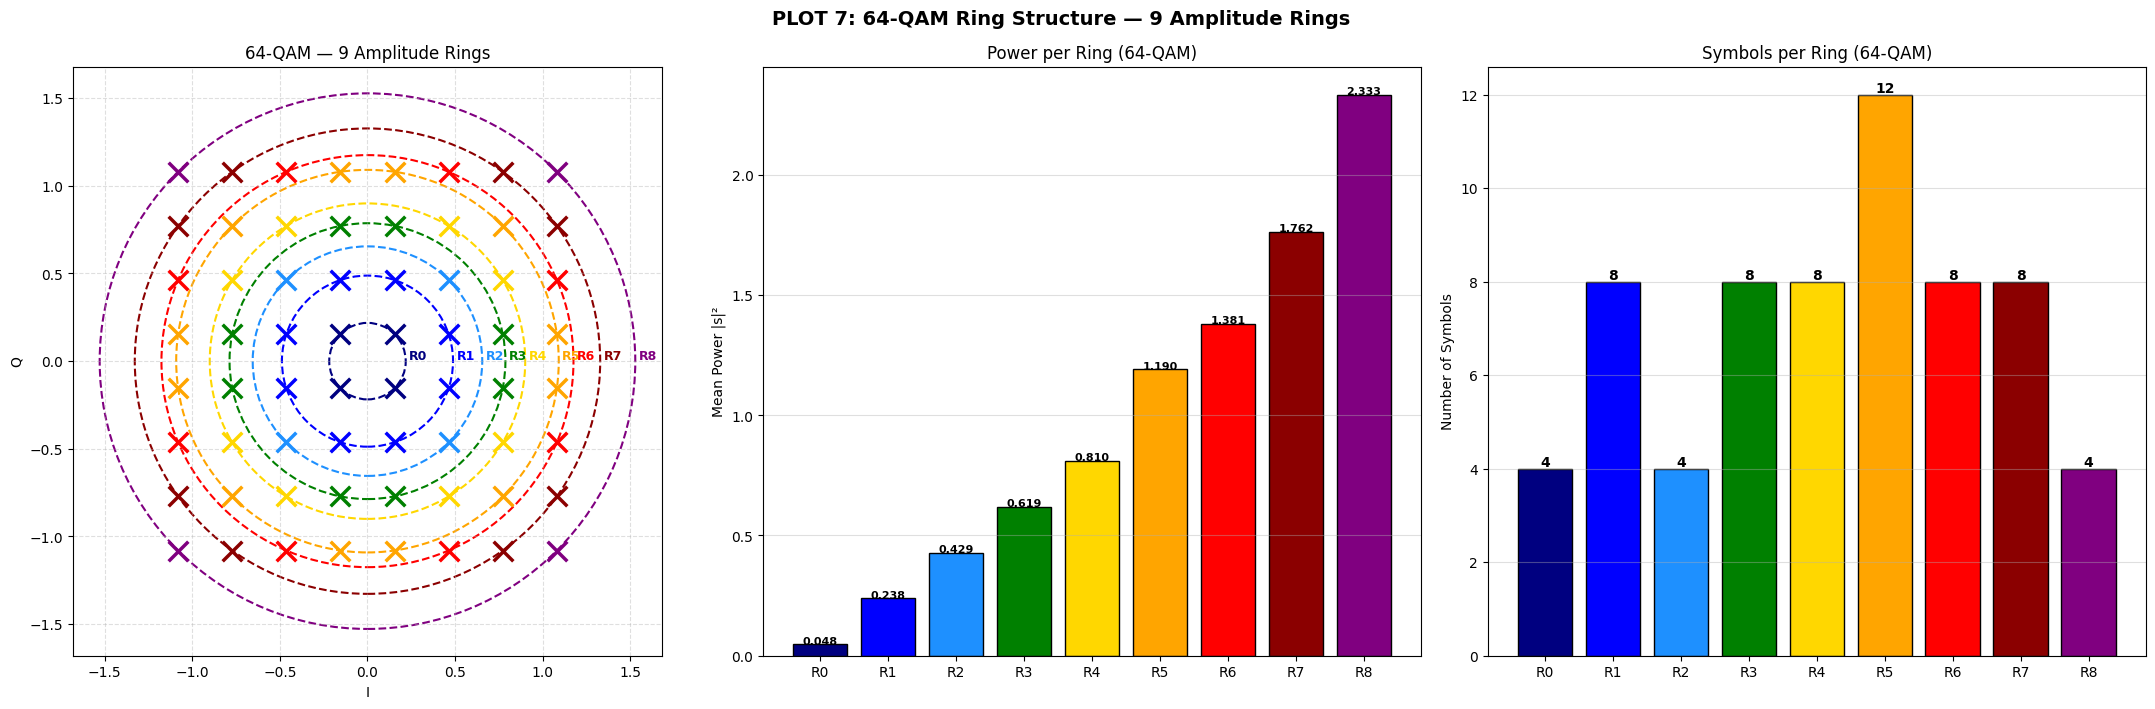

Saved: plot7_64qam_rings.png

  64-QAM TRIPLET EXTRACTION
Processing 29,360,128 positions in chunks...
  Processed 1,000,001 / 29,360,128
  Processed 6,000,001 / 29,360,128
  Processed 11,000,001 / 29,360,128
  Processed 16,000,001 / 29,360,128
  Processed 21,000,001 / 29,360,128
  Processed 26,000,001 / 29,360,128

Triplet Extraction Results:
  Symbol-Triplet max (M³)  : 64³ = 262,144  ← PAINFUL!
  Ring-Triplet max (R×M×R) : 9×64×9 = 5,184  ← MANAGEABLE
  Reduction factor         : 50.6× fewer GMMs
  Contexts found in data   : 433
  Avg samples per context  : 67806.30
  Min samples per context  : 1
  Max samples per context  : 266240

  64-QAM GMM FITTING

Fitting 433 GMMs...
Fitted : 432 GMMs
Skipped: 1 (fewer than 10 samples)

Example GMM (largest context):
  Ring0 → (-0.00708,+0.02124) → Ring0
  Samples : 266,240
  K (BIC) : 1

  Component 1: π = 1.0000
    μ = [I=-0.007022,  Q=+0.021259]
    Σ = | 0.000006  0.000000 |
        | 0.000000  0.000006 |
    std(I) = 0.002507   std(Q) =

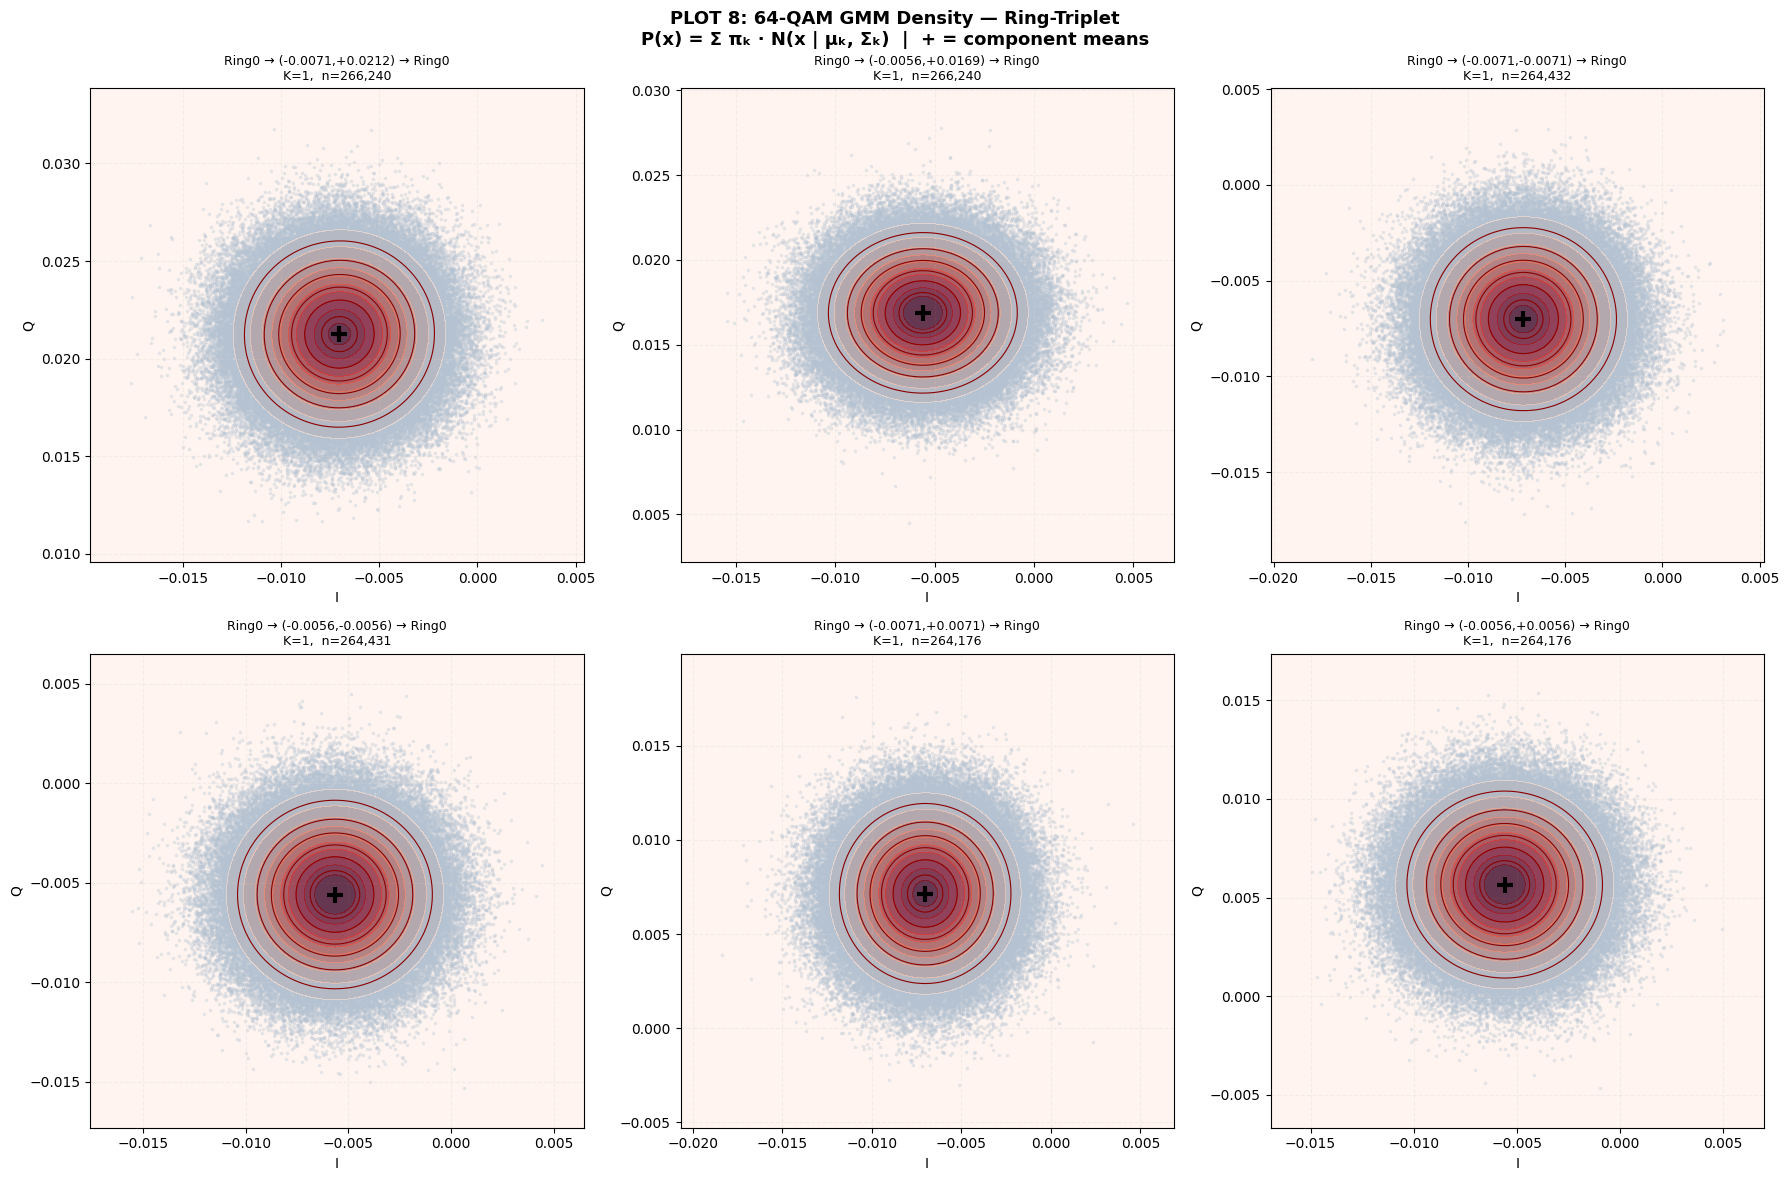

Saved: plot8_64qam_gmm_densities.png

64-QAM Ring-Triplet Log-Likelihood : 7.873576
In bits/symbol                      : 11.3592

  SCALABILITY SUMMARY
Metric                                    16-QAM        64-QAM
─────────────────────────────────────────────────────────────
Symbols M                                     16            64
Rings R                                        3             9
Symbol-Triplet M³                          4,096       262,144
Ring-Triplet R×M×R                           144         5,184
Reduction factor                           28.4×         50.6×
E[|s|²]                                     10.0          42.0
Power ratio outer/inner             9.0 (9.54dB)   49(16.90dB)
Symbol-triplet feasible?                Marginal            NO
─────────────────────────────────────────────────────────────

✓ 64-QAM Ring-Triplet   = 5,184 GMMs — FEASIBLE
✗ 64-QAM Symbol-Triplet = 262,144 GMMs — IMPOSSIBLE

Saved: gmm_B_64qam.pkl, ring_triplet_data_64.pkl, sym_

In [ ]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
import warnings
warnings.filterwarnings("ignore")

MIN_SAMPLES = 10
MAX_K       = 5

print("Loading saved arrays...")

def load_flat_numpy(path):
    """
    Load .npy file and flatten to 1D complex array.
    Uses numpy concatenate — no Python list, no MemoryError.
    """
    data = np.load(path, allow_pickle=True)

    if data.ndim == 1 and np.iscomplexobj(data):
        return data

    arrays = [np.array(item).flatten() for item in data]
    return np.concatenate(arrays).astype(complex)

tx_64       = load_flat_numpy("tx_symbols.npy")
rx_64       = load_flat_numpy("rx_samples.npy")
tx_rings_64 = np.load("tx_rings.npy")

print(f"tx_64 shape    : {tx_64.shape}")
print(f"rx_64 shape    : {rx_64.shape}")
print(f"tx_rings shape : {tx_rings_64.shape}")
print(f"tx_64[0]       : {tx_64[0]}  (must be a single complex number)")
print(f"type(tx_64[0]) : {type(tx_64[0])}")

N_64 = len(tx_64)
unique_symbols_64 = np.unique(tx_64)
M = len(unique_symbols_64)
print(f"\nUnique symbols : {M}")
print(f"Total symbols  : {N_64:,}")

print("\n" + "="*60)
print("  64-QAM RING STRUCTURE")
print("="*60)

levels_64     = np.array([-7, -5, -3, -1, 1, 3, 5, 7])
I_64, Q_64    = np.meshgrid(levels_64, levels_64)
unique_64_raw = (I_64 + 1j * Q_64).flatten()
power_norm    = np.sqrt(np.mean(np.abs(unique_64_raw)**2))
unique_64     = unique_64_raw / power_norm

unique_64_scalars = [complex(s) for s in unique_64]

print(f"64-QAM symbols : {len(unique_64_scalars)}")
print(f"E[|s|²] unnorm : {np.mean(np.abs(unique_64_raw)**2):.4f}")
print(f"E[|s|²] norm   : {np.mean(np.abs(unique_64)**2):.4f}")


N_RINGS_64 = 9
amps_64    = np.abs(unique_64)

print(f"\nUnique amplitudes (64-QAM):")
print(np.sort(np.unique(np.round(amps_64, 4))))

km_64      = KMeans(n_clusters=N_RINGS_64, n_init=30, random_state=0)
km_64.fit(amps_64.reshape(-1, 1))
labels_64  = km_64.labels_
centres_64 = km_64.cluster_centers_.flatten()
order_64   = np.argsort(centres_64)
remap_64   = {old: new for new, old in enumerate(order_64)}
labels_64  = np.array([remap_64[l] for l in labels_64])

sym_to_ring_64 = {complex(unique_64_scalars[i]): int(labels_64[i])
                  for i in range(len(unique_64_scalars))}

print(f"\n64-QAM Ring Distribution ({N_RINGS_64} rings):")
print(f"{'Ring':<8} {'Count':>6} {'Mean |s|':>12} {'Power |s|²':>12} {'dB above R0':>12}")
print(f"{'─'*54}")

pow_ring0 = None
for r in range(N_RINGS_64):
    syms_r   = [s for s, v in sym_to_ring_64.items() if v == r]
    mean_amp = np.mean([np.abs(s) for s in syms_r])
    mean_pow = mean_amp**2
    if r == 0:
        pow_ring0 = mean_pow
    db_above = 10 * np.log10(mean_pow / pow_ring0) if pow_ring0 > 0 else 0
    print(f"Ring {r}  {len(syms_r):>6}  {mean_amp:>12.4f}  {mean_pow:>12.4f}  {db_above:>10.2f} dB")

pow_inner_64 = np.mean([np.abs(s)**2 for s, v in sym_to_ring_64.items() if v == 0])
pow_outer_64 = np.mean([np.abs(s)**2 for s, v in sym_to_ring_64.items() if v == 8])
print(f"\nPower ratio Ring8/Ring0 = {pow_outer_64/pow_inner_64:.2f}")
print(f"  = {10*np.log10(pow_outer_64/pow_inner_64):.2f} dB")
print(f"  Outer ring causes {pow_outer_64/pow_inner_64:.0f}x more nonlinear interference!")

ring_colors_9 = {0:"navy", 1:"blue",    2:"dodgerblue",
                 3:"green",4:"gold",    5:"orange",
                 6:"red",  7:"darkred", 8:"purple"}

fig, axes = plt.subplots(1, 3, figsize=(22, 7))

ax = axes[0]
for s, r in sym_to_ring_64.items():
    ax.scatter(s.real, s.imag, color=ring_colors_9[r],
               s=200, marker="x", linewidths=2.5, zorder=5)
for r in range(N_RINGS_64):
    syms_r = [s for s, v in sym_to_ring_64.items() if v == r]
    radius = np.mean([np.abs(s) for s in syms_r])
    ax.add_patch(plt.Circle((0, 0), radius, fill=False,
                 color=ring_colors_9[r], linestyle="--", linewidth=1.5))
    ax.annotate(f"R{r}", xy=(radius + 0.02, 0.01),
                color=ring_colors_9[r], fontsize=9, fontweight="bold")
ax.set_aspect("equal"); ax.grid(True, linestyle="--", alpha=0.4)
ax.set_xlabel("I"); ax.set_ylabel("Q")
ax.set_title("64-QAM — 9 Amplitude Rings")

ax = axes[1]
ring_powers_64 = [np.mean([np.abs(s)**2 for s, v in sym_to_ring_64.items() if v == r])
                  for r in range(N_RINGS_64)]
bars = ax.bar([f"R{r}" for r in range(N_RINGS_64)], ring_powers_64,
              color=[ring_colors_9[r] for r in range(N_RINGS_64)],
              edgecolor="black")
for bar, val in zip(bars, ring_powers_64):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f"{val:.3f}", ha="center", fontsize=8, fontweight="bold")
ax.set_ylabel("Mean Power |s|²")
ax.set_title("Power per Ring (64-QAM)")
ax.grid(True, axis="y", alpha=0.4)

ax = axes[2]
ring_counts_64 = [sum(1 for v in sym_to_ring_64.values() if v == r)
                  for r in range(N_RINGS_64)]
bars = ax.bar([f"R{r}" for r in range(N_RINGS_64)], ring_counts_64,
              color=[ring_colors_9[r] for r in range(N_RINGS_64)],
              edgecolor="black")
for bar, val in zip(bars, ring_counts_64):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            str(val), ha="center", fontsize=10, fontweight="bold")
ax.set_ylabel("Number of Symbols")
ax.set_title("Symbols per Ring (64-QAM)")
ax.grid(True, axis="y", alpha=0.4)

plt.suptitle("PLOT 7: 64-QAM Ring Structure — 9 Amplitude Rings",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("plot7_64qam_rings.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: plot7_64qam_rings.png")


print("\n" + "="*60)
print("  64-QAM TRIPLET EXTRACTION")
print("="*60)
print(f"Processing {N_64:,} positions in chunks...")

CHUNK = 1_000_000
ring_triplet_data_64 = defaultdict(list)

for start in range(1, N_64 - 1, CHUNK):
    end = min(start + CHUNK, N_64 - 1)
    for t in range(start, end):
        prev_ring = int(tx_rings_64[t - 1])
        next_ring = int(tx_rings_64[t + 1])
        curr_sym  = complex(tx_64[t])
        rx_iq     = np.array([rx_64[t].real, rx_64[t].imag])
        ring_triplet_data_64[(prev_ring, curr_sym, next_ring)].append(rx_iq)

    if start % 5_000_000 == 1:
        print(f"  Processed {end:,} / {N_64:,}")

ring_triplet_data_64 = {k: np.array(v) for k, v in ring_triplet_data_64.items()}
counts_64 = [v.shape[0] for v in ring_triplet_data_64.values()]

print(f"\nTriplet Extraction Results:")
print(f"  Symbol-Triplet max (M³)  : 64³ = {64**3:,}  ← PAINFUL!")
print(f"  Ring-Triplet max (R×M×R) : 9×64×9 = {9*64*9:,}  ← MANAGEABLE")
print(f"  Reduction factor         : {64**3/(9*64*9):.1f}× fewer GMMs")
print(f"  Contexts found in data   : {len(ring_triplet_data_64):,}")
if counts_64:
    print(f"  Avg samples per context  : {np.mean(counts_64):.2f}")
    print(f"  Min samples per context  : {min(counts_64)}")
    print(f"  Max samples per context  : {max(counts_64)}")


print("\n" + "="*60)
print("  64-QAM GMM FITTING")
print("="*60)

def fit_gmm_64(points):
    n = points.shape[0]
    if n < MIN_SAMPLES:
        return None
    best_gmm, best_bic = None, np.inf
    for k in range(1, min(MAX_K + 1, n)):
        gmm = GaussianMixture(n_components=k, covariance_type="full",
                              max_iter=200, n_init=3, random_state=42)
        gmm.fit(points)
        bic = gmm.bic(points)
        if bic < best_bic:
            best_bic, best_gmm = bic, gmm
    return best_gmm

print(f"\nFitting {len(ring_triplet_data_64):,} GMMs...")
gmm_64  = {}
skip_64 = 0
for key, pts in ring_triplet_data_64.items():
    g = fit_gmm_64(pts)
    if g is not None:
        gmm_64[key] = g
    else:
        skip_64 += 1

print(f"Fitted : {len(gmm_64):,} GMMs")
print(f"Skipped: {skip_64} (fewer than {MIN_SAMPLES} samples)")

if gmm_64:
    best_key_64 = max(ring_triplet_data_64,
                      key=lambda k: ring_triplet_data_64[k].shape[0])
    g_ex  = gmm_64[best_key_64]
    sym64 = best_key_64[1]
    pts64 = ring_triplet_data_64[best_key_64]
    print(f"\nExample GMM (largest context):")
    print(f"  Ring{best_key_64[0]} → ({sym64.real:+.5f},{sym64.imag:+.5f}) → Ring{best_key_64[2]}")
    print(f"  Samples : {pts64.shape[0]:,}")
    print(f"  K (BIC) : {g_ex.n_components}")
    for k in range(g_ex.n_components):
        mu    = g_ex.means_[k]
        sigma = g_ex.covariances_[k]
        pi    = g_ex.weights_[k]
        print(f"\n  Component {k+1}: π = {pi:.4f}")
        print(f"    μ = [I={mu[0]:+.6f},  Q={mu[1]:+.6f}]")
        print(f"    Σ = | {sigma[0,0]:.6f}  {sigma[0,1]:.6f} |")
        print(f"        | {sigma[1,0]:.6f}  {sigma[1,1]:.6f} |")
        print(f"    std(I) = {np.sqrt(sigma[0,0]):.6f}   std(Q) = {np.sqrt(sigma[1,1]):.6f}")

k_counts_64 = {}
for g in gmm_64.values():
    k_counts_64[g.n_components] = k_counts_64.get(g.n_components, 0) + 1
print(f"\nBIC Component Selection:")
for k in sorted(k_counts_64.keys()):
    pct = 100 * k_counts_64[k] / max(len(gmm_64), 1)
    bar = "█" * int(pct / 2)
    print(f"  K={k}: {k_counts_64[k]:4d} contexts ({pct:5.1f}%)  {bar}")


if len(gmm_64) >= 6:
    top6_64 = sorted(ring_triplet_data_64.keys(),
                     key=lambda k: ring_triplet_data_64[k].shape[0],
                     reverse=True)[:6]
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    fig.suptitle("PLOT 8: 64-QAM GMM Density — Ring-Triplet\n"
                 "P(x) = Σ πₖ · N(x | μₖ, Σₖ)  |  + = component means",
                 fontsize=13, fontweight="bold")

    def plot_gmm_density_64(gmm, pts, title, ax, n_grid=120):
        span_x = pts[:, 0].max() - pts[:, 0].min()
        span_y = pts[:, 1].max() - pts[:, 1].min()
        margin = max(0.002, max(span_x, span_y) * 0.1)
        xi = np.linspace(pts[:, 0].min() - margin, pts[:, 0].max() + margin, n_grid)
        yi = np.linspace(pts[:, 1].min() - margin, pts[:, 1].max() + margin, n_grid)
        XX, YY = np.meshgrid(xi, yi)
        XY  = np.column_stack([XX.ravel(), YY.ravel()])
        pdf = np.exp(gmm.score_samples(XY)).reshape(n_grid, n_grid)
        ax.scatter(pts[:, 0], pts[:, 1], s=3, alpha=0.25, color="steelblue", zorder=1)
        ax.contourf(XX, YY, pdf, levels=10, cmap="Reds", alpha=0.6, zorder=2)
        ax.contour(XX, YY, pdf, levels=6, colors="darkred", linewidths=0.8, zorder=3)
        for mean in gmm.means_:
            ax.scatter(*mean, s=120, marker="+", color="black", linewidths=3, zorder=6)
        ax.set_title(title, fontsize=9)
        ax.set_xlabel("I"); ax.set_ylabel("Q")
        ax.grid(True, linestyle="--", alpha=0.3)

    for ax, key in zip(axes.flat, top6_64):
        if key in gmm_64:
            pts = ring_triplet_data_64[key]
            s   = key[1]
            g   = gmm_64[key]
            plot_gmm_density_64(g, pts,
                f"Ring{key[0]} → ({s.real:+.4f},{s.imag:+.4f}) → Ring{key[2]}\n"
                f"K={g.n_components},  n={pts.shape[0]:,}", ax)
    plt.tight_layout()
    plt.savefig("plot8_64qam_gmm_densities.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved: plot8_64qam_gmm_densities.png")


if gmm_64:
    total_ll_64, total_n_64 = 0.0, 0
    for key, pts in ring_triplet_data_64.items():
        if key in gmm_64 and pts.shape[0] >= 2:
            total_ll_64 += gmm_64[key].score(pts) * pts.shape[0]
            total_n_64  += pts.shape[0]
    ll_64 = total_ll_64 / total_n_64 if total_n_64 > 0 else np.nan
    print(f"\n64-QAM Ring-Triplet Log-Likelihood : {ll_64:.6f}")
    print(f"In bits/symbol                      : {ll_64/np.log(2):.4f}")

print("\n" + "="*60)
print("  SCALABILITY SUMMARY")
print("="*60)
print(f"{'Metric':<35} {'16-QAM':>12}  {'64-QAM':>12}")
print(f"{'─'*61}")
print(f"{'Symbols M':<35} {'16':>12}  {'64':>12}")
print(f"{'Rings R':<35} {'3':>12}  {'9':>12}")
print(f"{'Symbol-Triplet M³':<35} {16**3:>12,}  {64**3:>12,}")
print(f"{'Ring-Triplet R×M×R':<35} {3*16*3:>12,}  {9*64*9:>12,}")
print(f"{'Reduction factor':<35} {16**3/(3*16*3):>11.1f}×  {64**3/(9*64*9):>11.1f}×")
print(f"{'E[|s|²]':<35} {'10.0':>12}  {'42.0':>12}")
print(f"{'Power ratio outer/inner':<35} {'9.0 (9.54dB)':>12}  {'49(16.90dB)':>12}")
print(f"{'Symbol-triplet feasible?':<35} {'Marginal':>12}  {'NO':>12}")
print(f"{'─'*61}")
print(f"\n✓ 64-QAM Ring-Triplet   = {9*64*9:,} GMMs — FEASIBLE")
print(f"✗ 64-QAM Symbol-Triplet = {64**3:,} GMMs — IMPOSSIBLE")


with open("gmm_B_64qam.pkl",         "wb") as f: pickle.dump(gmm_64, f)
with open("ring_triplet_data_64.pkl", "wb") as f: pickle.dump(ring_triplet_data_64, f)
with open("sym_to_ring_64.pkl",       "wb") as f: pickle.dump(sym_to_ring_64, f)
print("\nSaved: gmm_B_64qam.pkl, ring_triplet_data_64.pkl, sym_to_ring_64.pkl")